# 02 — Random Forest: Probabilidade de Churn
## PRT Seguros

Ensemble de árvores via bagging. Não precisa de padronização de features. `class_weight='balanced_subsample'` compensa o desbalanceamento em cada árvore.

## 1. Imports e carregar dados processados

Os dados já vêm prontos do notebook `00_preparacao_dados.ipynb`: **treino e validação já vêm
separados** (o split foi feito antes de qualquer ajuste de imputer/scaler/K-Means, para não vazar
informação da validação para dentro do pré-processamento), com as mesmas features e a mesma
clusterização — para que o AUC-ROC de todos os modelos seja comparável.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42

train = pd.read_csv("dados_processados/train_model_ready.csv")
val = pd.read_csv("dados_processados/val_model_ready.csv")
kaggle = pd.read_csv("dados_processados/kaggle_model_ready.csv")

ID_COL, TARGET_COL = "cod_individuo", "churned"
feature_cols = [c for c in train.columns if c not in (ID_COL, TARGET_COL)]

X_train, y_train = train[feature_cols], train[TARGET_COL]
X_val, y_val = val[feature_cols], val[TARGET_COL]
X_kaggle = kaggle[feature_cols]

print(f"Treino : {X_train.shape} | churn = {y_train.mean():.1%}")
print(f"Val    : {X_val.shape} | churn = {y_val.mean():.1%}")
print(f"Kaggle : {X_kaggle.shape}")


Treino : (80000, 72) | churn = 12.1%
Val    : (20000, 72) | churn = 12.1%
Kaggle : (100000, 72)


## 2. Treinar o modelo

In [2]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf.fit(X_train, y_train)

proba_val = rf.predict_proba(X_val)[:, 1]


## 3. Avaliar no conjunto de validação (AUC-ROC)

A métrica que importa aqui é o **AUC-ROC da probabilidade prevista** (`predict_proba`), não a acurácia da classificação binária — é isso que o projeto pediu para maximizar.

In [3]:
auc_val = roc_auc_score(y_val, proba_val)
print(f"ROC-AUC (validação) — Random Forest: {auc_val:.4f}")

ROC-AUC (validação) — Random Forest: 0.8196


## 4. Curva ROC

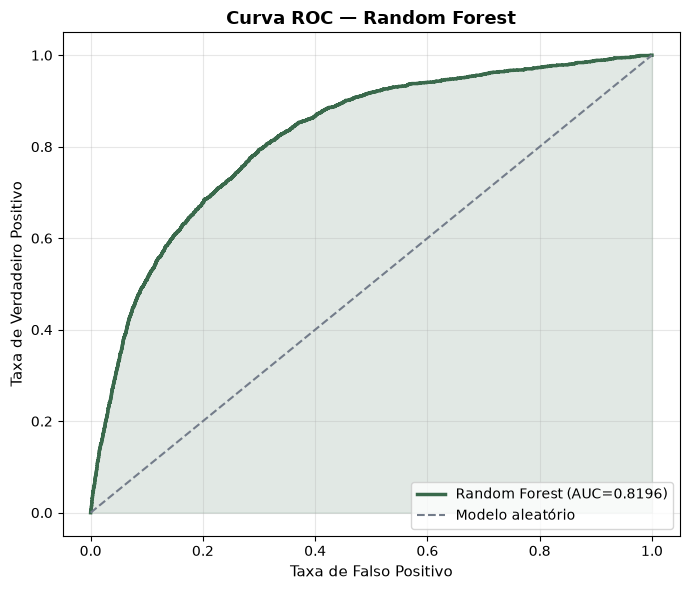

In [4]:
fpr, tpr, _ = roc_curve(y_val, proba_val)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Random Forest (AUC={auc_val:.4f})", color=PRT_GREEN, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle="--", color=PRT_GRAY, label="Modelo aleatório")
ax.fill_between(fpr, tpr, alpha=0.15, color=PRT_GREEN)
ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC — Random Forest", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Prever probabilidade de churn na base Kaggle

Aqui geramos a saída que o projeto pediu: uma **probabilidade contínua entre 0 e 1** de churn para cada indivíduo da base de teste (`Base_Unificada_Kaggle_Outer.csv`), não um rótulo binário.

In [5]:
os.makedirs("submissions", exist_ok=True)

proba_kaggle = rf.predict_proba(X_kaggle)[:, 1]

submissao = pd.DataFrame({
    "Id": kaggle[ID_COL],
    "probabilidade_churn": proba_kaggle,
})
submissao.to_csv("submissions/submission_random_forest.csv", index=False)
print(submissao.head())
print(f"\nProbabilidade média de churn prevista no Kaggle: {proba_kaggle.mean():.2%}")


             Id  probabilidade_churn
0  221300000002             0.104093
1  221300000020             0.183872
2  221300000097             0.139217
3  221300000148             0.338723
4  221300000166             0.304814

Probabilidade média de churn prevista no Kaggle: 33.01%


## 6. Registrar resultado para comparação final

In [6]:
os.makedirs("dados_processados", exist_ok=True)
resultados_path = "dados_processados/resultados_modelos.csv"

linha = pd.DataFrame([{
    "modelo": "random_forest",
    "auc_roc_val": auc_val,
}])

if os.path.exists(resultados_path):
    resultados = pd.read_csv(resultados_path)
    resultados = resultados[resultados["modelo"] != "random_forest"]
    resultados = pd.concat([resultados, linha], ignore_index=True)
else:
    resultados = linha

resultados.to_csv(resultados_path, index=False)
print(resultados.sort_values("auc_roc_val", ascending=False).to_string(index=False))


             modelo  auc_roc_val
           catboost     0.825413
            xgboost     0.823997
           lightgbm     0.823799
      random_forest     0.819568
logistic_regression     0.803300


## 7. Salvar probabilidades da validação (para blending)

Guardamos `proba_val` em disco — o notebook `08_blending.ipynb` combina as previsões de todos os modelos sobre o **mesmo** conjunto de validação.

In [7]:
os.makedirs("dados_processados/proba_val", exist_ok=True)
pd.DataFrame({
    "cod_individuo": val[ID_COL],
    "proba": proba_val,
}).to_csv("dados_processados/proba_val/random_forest.csv", index=False)
print("Salvo: dados_processados/proba_val/random_forest.csv")

Salvo: dados_processados/proba_val/random_forest.csv
